In [1]:

import json
import pandas as pd
from pathlib import Path
import joblib
import matplotlib.pyplot as plt

# OPTIONAL SHAP
USE_SHAP = False
if USE_SHAP:
    import shap

# =========================
# CONFIG
# =========================
BASE_DIR = Path("C:/IDEAL_Programming")

MODELS_BASE = BASE_DIR / "processed" / "models"

# 👉 ΕΝΙΑΙΟΣ ΦΑΚΕΛΟΣ ΑΠΟΤΕΛΕΣΜΑΤΩΝ
OUTPUT_DIR = MODELS_BASE / "feature_importance_unified"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TOP_N = 15

MODEL_CONFIG = {
    "rf": MODELS_BASE / "final_rf",
    "xgb": MODELS_BASE / "final_xgb",
    "lgbm": MODELS_BASE / "final_lgbm",
}

MODES = ["coldstart", "withhistory"]

# =========================
# HELPERS
# =========================
def load_json(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)

def extract_importance(model):
    return model.feature_importances_

def save_outputs(df, prefix):
    csv_path = OUTPUT_DIR / f"{prefix}_importance.csv"
    json_path = OUTPUT_DIR / f"{prefix}_importance.json"
    plot_path = OUTPUT_DIR / f"{prefix}_importance.png"

    df.to_csv(csv_path, index=False)
    df.to_json(json_path, orient="records", indent=2)

    # Plot
    df_top = df.head(TOP_N).iloc[::-1]

    plt.figure()
    plt.barh(df_top["feature"], df_top["importance_pct"])
    plt.xlabel("Importance (%)")
    plt.title(prefix)
    plt.tight_layout()
    plt.savefig(plot_path, dpi=300)
    plt.close()

    print(f"Saved: {csv_path}")
    print(f"Saved: {json_path}")
    print(f"Saved: {plot_path}")

def run_shap(model, feature_names, prefix):
    if not USE_SHAP:
        return

    print(f"Running SHAP for {prefix}...")

    try:
        import numpy as np
        X_dummy = pd.DataFrame(
            np.zeros((200, len(feature_names))),
            columns=feature_names
        )

        explainer = shap.TreeExplainer(model)
        shap_values = explainer.shap_values(X_dummy)

        shap.summary_plot(shap_values, X_dummy, show=False)

        shap_path = OUTPUT_DIR / f"{prefix}_shap.png"
        plt.savefig(shap_path, dpi=300)
        plt.close()

        print(f"Saved SHAP: {shap_path}")

    except Exception as e:
        print(f"SHAP skipped: {e}")

# =========================
# MAIN
# =========================
all_results = []

for model_name, model_dir in MODEL_CONFIG.items():

    print(f"\n=========================")
    print(f"MODEL: {model_name.upper()}")
    print(f"=========================")

    for mode in MODES:

        print(f"\n--- Mode: {mode} ---")

        model_path = model_dir / f"{model_name}_{mode}.joblib"
        features_path = model_dir / f"{model_name}_{mode}_feature_columns.json"

        if not model_path.exists():
            print(f"Missing model: {model_path}")
            continue

        if not features_path.exists():
            print(f"Missing features: {features_path}")
            continue

        # Load
        model = joblib.load(model_path)
        feature_names = load_json(features_path)

        # Importance
        importances = extract_importance(model)

        df = pd.DataFrame({
            "feature": feature_names,
            "importance": importances
        }).sort_values("importance", ascending=False)

        df["importance_pct"] = 100 * df["importance"] / df["importance"].sum()

        prefix = f"{model_name}_{mode}"

        # Save individual outputs
        save_outputs(df, prefix)

        # Store for comparison
        df_temp = df.copy()
        df_temp["model"] = model_name
        df_temp["mode"] = mode
        all_results.append(df_temp)

        print("\nTop 10 features:")
        print(df.head(10))

        # SHAP
        run_shap(model, feature_names, prefix)

# =========================
# COMBINED COMPARISON FILE
# =========================
if all_results:
    df_all = pd.concat(all_results, ignore_index=True)

    combined_path = OUTPUT_DIR / "all_models_feature_importance.csv"
    df_all.to_csv(combined_path, index=False)

    print(f"\nSaved combined file: {combined_path}")

print("\nDone.")




MODEL: RF

--- Mode: coldstart ---


C:\Users\z0050azt\AppData\Roaming\Python\Python310\site-packages\sklearn\base.py:440: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.7.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\z0050azt\AppData\Roaming\Python\Python310\site-packages\sklearn\base.py:440: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.7.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Saved: C:\IDEAL_Programming\processed\models\feature_importance_unified\rf_coldstart_importance.csv
Saved: C:\IDEAL_Programming\processed\models\feature_importance_unified\rf_coldstart_importance.json
Saved: C:\IDEAL_Programming\processed\models\feature_importance_unified\rf_coldstart_importance.png

Top 10 features:
                       feature  importance  importance_pct
5          total_floor_area_m2    0.395750       39.575015
0                         hour    0.267388       26.738786
6                    residents    0.099027        9.902665
4         external_temperature    0.072835        7.283541
3                        month    0.055927        5.592693
1                  day_of_week    0.034381        3.438063
9          urban_rural_class_1    0.016615        1.661513
8   hometype_house_or_bungalow    0.015677        1.567709
7                hometype_flat    0.015496        1.549630
10         urban_rural_class_2    0.011981        1.198115

--- Mode: withhistory ---


C:\Users\z0050azt\AppData\Roaming\Python\Python310\site-packages\sklearn\base.py:440: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.7.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
C:\Users\z0050azt\AppData\Roaming\Python\Python310\site-packages\sklearn\base.py:440: InconsistentVersionWarning: Trying to unpickle estimator RandomForestRegressor from version 1.7.1 when using version 1.7.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


Saved: C:\IDEAL_Programming\processed\models\feature_importance_unified\rf_withhistory_importance.csv
Saved: C:\IDEAL_Programming\processed\models\feature_importance_unified\rf_withhistory_importance.json
Saved: C:\IDEAL_Programming\processed\models\feature_importance_unified\rf_withhistory_importance.png

Top 10 features:
                 feature  importance  importance_pct
7                 lag_1h    0.616456       61.645641
8                lag_24h    0.151946       15.194582
10        roll_mean_168h    0.068809        6.880926
0                   hour    0.053648        5.364767
9          roll_mean_24h    0.041140        4.114033
5    total_floor_area_m2    0.021820        2.181988
4   external_temperature    0.015873        1.587334
1            day_of_week    0.008500        0.849976
3                  month    0.007827        0.782673
6              residents    0.006029        0.602897

MODEL: XGB

--- Mode: coldstart ---
Saved: C:\IDEAL_Programming\processed\models\feature_im

Starting EDA feature importance analysis...
Loading dataset from: C:\IDEAL_Programming\processed\final\IDEAL_final_hourly_dataset.csv
Dataset loaded: (1529350, 32)

Columns found:
['home_id', 'timestamp', 'consumption_Wh', 'internal_temperature', 'external_temperature', 'residents', 'hometype', 'build_era', 'location', 'urban_rural_class', 'income_band', 'occupancy', 'total_floor_area_m2', 'num_rooms', 'avg_room_area_m2', 'num_external_windows', 'num_external_walls', 'num_appliances', 'num_electric_appliances', 'num_gas_appliances', 'num_children', 'num_adults', 'num_elderly', 'num_working_adults', 'num_full_time_workers', 'num_part_time_workers', 'num_males', 'num_females', 'hour', 'day_of_week', 'is_weekend', 'is_holiday']

Target column detected: consumption_Wh
Initial feature shape: (1529350, 29)


C:\Users\z0050azt\AppData\Local\Temp\ipykernel_7916\404637603.py:66: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  X[col] = pd.to_numeric(X[col], errors="ignore")


Shape after cleaning and encoding: (1529350, 63)
Final training shape: (1529350, 63)
Training Random Forest...
Training complete.

Top 20 features:
                feature  importance
   external_temperature    0.250608
   internal_temperature    0.209359
                   hour    0.188785
            day_of_week    0.081665
    total_floor_area_m2    0.044656
   num_external_windows    0.024944
     num_external_walls    0.017797
     num_gas_appliances    0.016113
num_electric_appliances    0.013658
             is_weekend    0.011653
       avg_room_area_m2    0.011088
         num_appliances    0.010841
              num_males    0.009587
              num_rooms    0.008562
             is_holiday    0.007571
  num_full_time_workers    0.007234
              residents    0.007133
  num_part_time_workers    0.006471
     num_working_adults    0.005957
             num_adults    0.004622

Saved full importance table to: C:\IDEAL_Programming\processed\feature_importance_full.csv


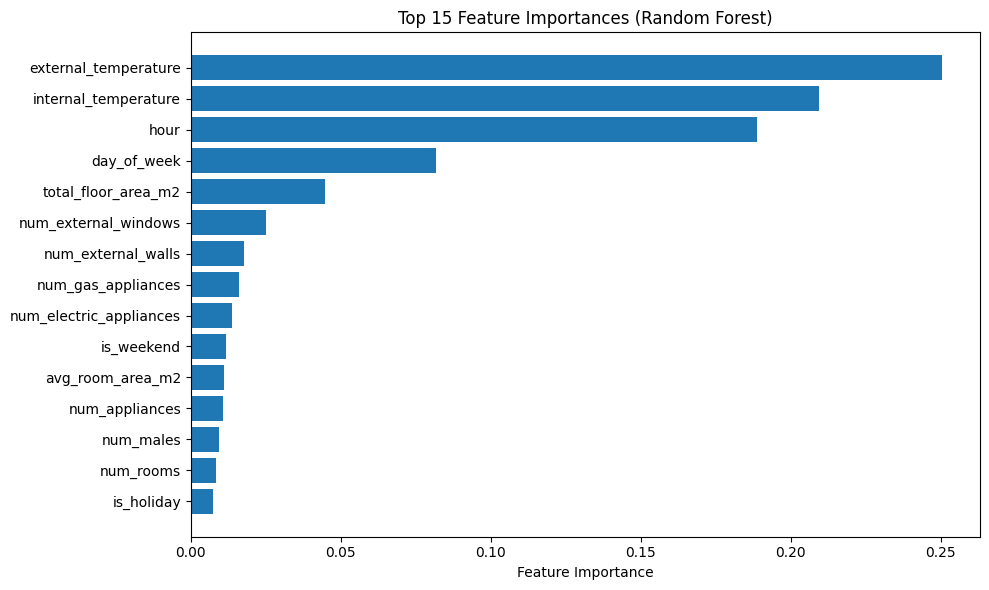

Done.


In [4]:
# C:/IDEAL_Programming/src/eda_feature_importance.py

from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split

print("Starting EDA feature importance analysis...")

BASE_DIR = Path("C:/IDEAL_Programming")
DATA_PATH = BASE_DIR / "processed" / "final" / "IDEAL_final_hourly_dataset.csv"
OUT_PATH = BASE_DIR / "processed" / "feature_importance_full.csv"

if not DATA_PATH.exists():
    raise FileNotFoundError(f"Dataset not found: {DATA_PATH}")

print(f"Loading dataset from: {DATA_PATH}")
df = pd.read_csv(DATA_PATH, low_memory=False)
print("Dataset loaded:", df.shape)

print("\nColumns found:")
print(df.columns.tolist())

# -----------------------------
# Detect target column
# -----------------------------
possible_targets = ["consumption_Wh", "target_Wh", "load_Wh", "y"]
target_col = None
for c in possible_targets:
    if c in df.columns:
        target_col = c
        break

if target_col is None:
    raise KeyError(
        "Could not find target column. Expected one of: "
        f"{possible_targets}"
    )

print(f"\nTarget column detected: {target_col}")

# -----------------------------
# Drop columns we should not use
# -----------------------------
drop_cols = [target_col]

for c in ["timestamp", "home_id", "datetime", "date", "time", "Unnamed: 0"]:
    if c in df.columns:
        drop_cols.append(c)

X = df.drop(columns=drop_cols, errors="ignore").copy()
y = pd.to_numeric(df[target_col], errors="coerce")

print("Initial feature shape:", X.shape)

# -----------------------------
# Remove completely empty columns
# -----------------------------
X = X.dropna(axis=1, how="all")

# -----------------------------
# Try numeric conversion where possible
# -----------------------------
for col in X.columns:
    X[col] = pd.to_numeric(X[col], errors="ignore")

# -----------------------------
# One-hot encode categorical columns
# -----------------------------
X = pd.get_dummies(X, dummy_na=False)

# -----------------------------
# Combine and clean
# -----------------------------
full = pd.concat([X, y.rename(target_col)], axis=1)
full = full.dropna()

y = full[target_col]
X = full.drop(columns=[target_col])

print("Shape after cleaning and encoding:", X.shape)

if X.empty:
    raise ValueError("Feature matrix is empty after cleaning.")

if len(X) < 100:
    print("Warning: dataset is quite small after cleaning:", len(X))

# Optional: sample rows if dataset is too big
MAX_ROWS = 5000000
if len(X) > MAX_ROWS:
    print(f"Sampling {MAX_ROWS} rows for faster execution...")
    sampled = full.sample(MAX_ROWS, random_state=42)
    y = sampled[target_col]
    X = sampled.drop(columns=[target_col])

print("Final training shape:", X.shape)

# -----------------------------
# Train / Test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Random Forest...")
model = RandomForestRegressor(
    n_estimators=50,
    random_state=42,
    n_jobs=-1
)
model.fit(X_train, y_train)
print("Training complete.")

# -----------------------------
# Feature Importance
# -----------------------------
importance_df = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values("importance", ascending=False)

print("\nTop 20 features:")
print(importance_df.head(20).to_string(index=False))

importance_df.to_csv(OUT_PATH, index=False, encoding="utf-8")
print(f"\nSaved full importance table to: {OUT_PATH}")

# -----------------------------
# Plot top 15
# -----------------------------
top15 = importance_df.head(15).sort_values("importance", ascending=True)

plt.figure(figsize=(10, 6))
plt.barh(top15["feature"], top15["importance"])
plt.xlabel("Feature Importance")
plt.title("Top 15 Feature Importances (Random Forest)")
plt.tight_layout()
plt.show()

print("Done.")